# PH2 проект

Цель данного проекта — построить и исследовать базовый пайплайн для задачи **бинарной сегментации кожных образований (lesion vs background)** на дерматоскопических изображениях из датасета **PH2**.

Проект реализован как небольшой **segmentation playground**, в котором последовательно рассматриваются основные компоненты сегментационного пайплайна и анализируется их влияние на качество модели.

В рамках проекта решаются следующие задачи:

- подготовка и проверка датасета (dataset, dataloaders, sanity checks);
- визуализация изображений и масок;
- реализация базовой архитектуры **U-Net** без предобученных весов;
- обучение модели и анализ метрик сегментации (**Dice, IoU**);
- сравнение различных **функций потерь**;
- исследование влияния **ширины модели (model capacity)**;
- анализ влияния **порога бинаризации (threshold)**;
- сравнение baseline модели с **U-Net с предобученным encoder-ом**;
- визуальный анализ ошибок и сложных примеров.

Основная цель экспериментов — понять, какие факторы сильнее всего влияют на качество сегментации на небольшом медицинском датасете и какие архитектурные решения позволяют добиться наилучших результатов.

## Setup

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models
from torchvision.transforms import functional as TF

In [2]:
CFG = {
    'seed': 42,
    'img_size': (256, 256),
    'batch_size': 8,
    'num_workers': 0,
    'val_ratio': 0.2,
    'pin_memory': True
}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('device :', device)
print('torch version:', torch.__version__)

device : cuda
torch version: 2.6.0.dev20241112+cu121


Подготовим функцию для правильного resize изображения, чтобы не растягивать картинку по одной оси

In [3]:
def resize_with_pad(img, target_hw=(256, 256), is_mask=False):
    # просто добавляем padding до target_hw

    target_h, target_w = target_hw
    w, h = img.size

    scale = min(target_w / w, target_h / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    interp = TF.InterpolationMode.NEAREST if is_mask else TF.InterpolationMode.BILINEAR
    img = TF.resize(img, (new_h, new_w), interpolation=interp)

    pad_w = target_w - new_w
    pad_h = target_h - new_h
    left = pad_w // 2
    right = pad_w - left
    top = pad_h // 2
    bottom = pad_h - top

    img = TF.pad(img, padding=[left, top, right, bottom], fill=0)

    meta = {
        'orig_hw': (h, w),
        'new_hw': (new_h, new_w),
        'target_hw': (target_h, target_w),
        'scale': scale,
        'pad': (left, top, right, bottom)
    }

    return img, meta

Теперь создадим PH2 датасет для бинарной сегментации

In [4]:
class PH2SegDataset(Dataset):
    def __init__(self, images_root, target_hw=(256, 256), augment=False):
        self.images_root = Path(images_root)
        self.target_hw = target_hw
        self.augment = augment

        self.items = self._collect_items()
    
    def _collect_items(self):
        items = []
        for case_dir in sorted(self.images_root.glob('IMD*')):
            case_id = case_dir.name
            
            img_path = case_dir / f'{case_id}_Dermoscopic_Image' / f'{case_id}.bmp'
            mask_path = case_dir / f'{case_id}_lesion' / f'{case_id}_lesion.bmp'

            if img_path.exists() and mask_path.exists():
                items.append((case_id, img_path, mask_path))

        return items
    
    def __len__(self):
        return len(self.items)
    
    @staticmethod
    def _mask_to_01_float(mask_pil):
        arr = np.array(mask_pil)
        arr = (arr > 0).astype(np.float32)
        return torch.from_numpy(arr)[None, ...]
    
    def __getitem__(self, idx):
        case_id, img_path, mask_path = self.items[idx]

        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        img, meta_img = resize_with_pad(img, target_hw=self.target_hw, is_mask=False)
        mask, meta_mask = resize_with_pad(mask, target_hw=self.target_hw, is_mask=True)

        if meta_img['pad'] != meta_mask['pad'] or meta_img['new_hw'] != meta_mask['new_hw']:
            raise RuntimeError(f'Несовпадение геометрии image/mask для {case_id}: {meta_img} vs {meta_mask}')
        
        img_t = TF.to_tensor(img)
        mask_t = self._mask_to_01_float(mask)

        return {
            'id': case_id,
            'image': img_t,
            'mask': mask_t,
            'meta': meta_img
        }


Посмотрим 1 sample

In [5]:
PH2_IMAGES_ROOT = Path(r"./PH2Dataset/PH2 Dataset images")

ds = PH2SegDataset(
    images_root=PH2_IMAGES_ROOT,
    target_hw=CFG['img_size'],
    augment=False
)

print('dataset size:', len(ds))

sample = ds[0]
img = sample['image']
mask = sample['mask']
meta = sample['meta']

print('id:', sample['id'])
print('image:', img.shape, img.dtype, float(img.min()), float(img.max()))
print('mask :', mask.shape, mask.dtype, float(mask.min()), float(mask.max()))
print('mask unique:', torch.unique(mask))
print('meta:', meta)

dataset size: 200
id: IMD002
image: torch.Size([3, 256, 256]) torch.float32 0.0 0.9803921580314636
mask : torch.Size([1, 256, 256]) torch.float32 0.0 1.0
mask unique: tensor([0., 1.])
meta: {'orig_hw': (572, 765), 'new_hw': (191, 256), 'target_hw': (256, 256), 'scale': 0.33464052287581697, 'pad': (0, 32, 0, 33)}


Делаем random split и инициализируем DataLoaders

In [6]:
n_total = len(ds)
n_val = int(n_total * CFG['val_ratio'])
n_train = n_total - n_val

train_ds, val_ds = random_split(
    ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(CFG['seed'])
)
print('sizes:', n_total, n_train, n_val)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print('train batches:', len(train_loader), 'val batches:', len(val_loader))

sizes: 200 160 40
train batches: 20 val batches: 5


Sanity-check

In [7]:
batch = next(iter(train_loader))

imgs = batch['image']
masks = batch['mask']

print('image:', imgs.shape, imgs.dtype, float(imgs.min()), float(imgs.max()))
print('mask :', masks.shape, masks.dtype, float(masks.min()), float(masks.max()))

uniq = torch.unique(masks)
print('mask unique:', uniq)

lesion_ratio = masks.mean().item()
print('mean lesion pixel ratio:', lesion_ratio)

image: torch.Size([8, 3, 256, 256]) torch.float32 0.0 1.0
mask : torch.Size([8, 1, 256, 256]) torch.float32 0.0 1.0
mask unique: tensor([0., 1.])
mean lesion pixel ratio: 0.2965087890625


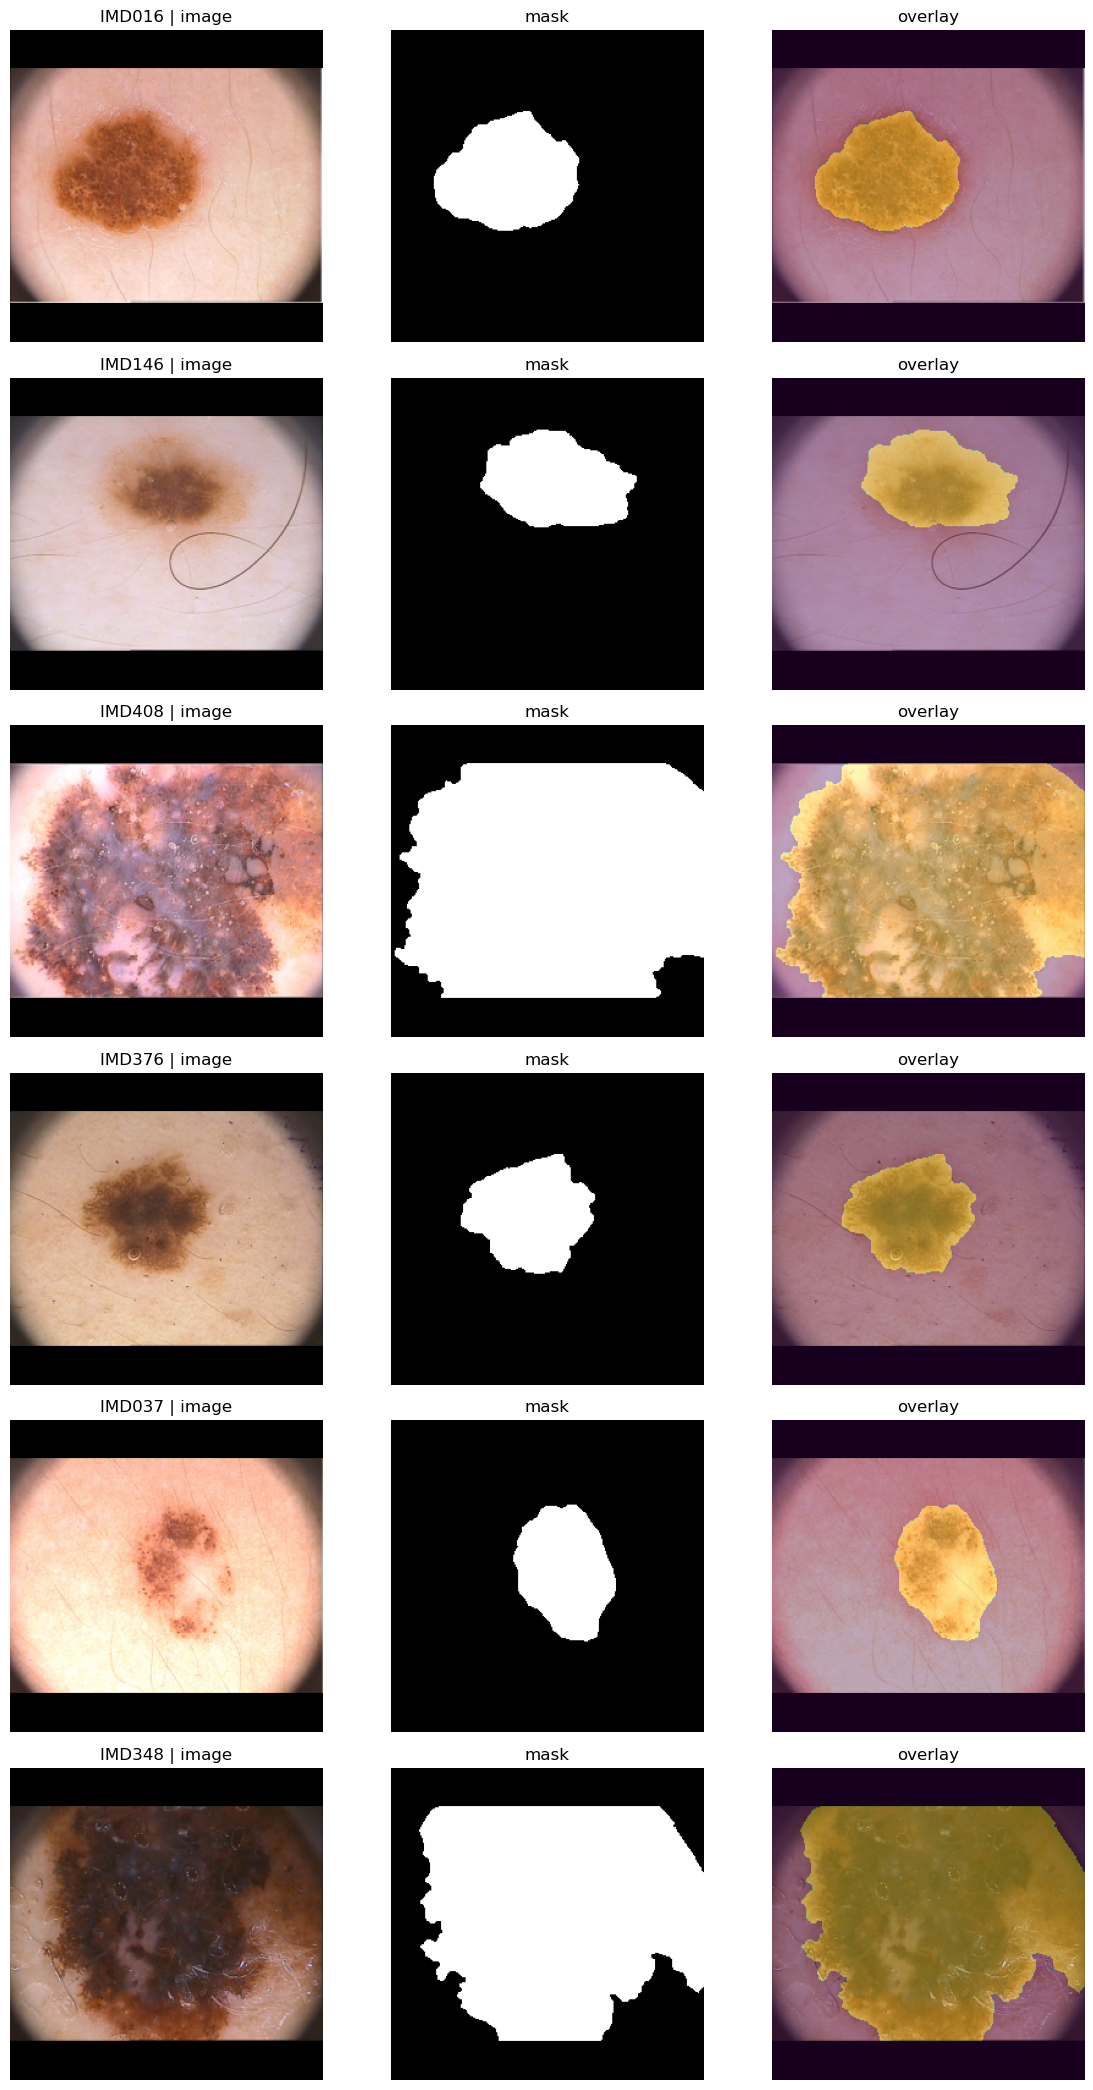

In [8]:
def show_batch_overlay(batch, n=6):

    imgs = batch['image'][:n]
    masks = batch['mask'][:n]
    ids = batch['id'][:n]

    plt.figure(figsize=(12, 3.5*n))
    
    for i in range(n):
        img = imgs[i].permute(1, 2, 0).cpu().numpy()
        mask = masks[i, 0].cpu().numpy()

        ax1 = plt.subplot(n, 3, 3*i + 1)
        ax1.imshow(img)
        ax1.set_title(f"{ids[i]} | image")
        ax1.axis("off")

        ax2 = plt.subplot(n, 3, 3*i + 2)
        ax2.imshow(mask, cmap="gray")
        ax2.set_title("mask")
        ax2.axis("off")

        ax3 = plt.subplot(n, 3, 3*i + 3)
        ax3.imshow(img)
        ax3.imshow(mask, alpha=0.35)  
        ax3.set_title("overlay")
        ax3.axis("off")

    plt.tight_layout()
    plt.show()

show_batch_overlay(batch, n=6)

## Loss/Metrics

### Метрики

Сделаем soft Dice, чтобы считать метрику без порога и позже использовать для DiceLoss

In [9]:
@torch.no_grad()
def dice_score(probs, target, eps=1e-7):
    probs = probs.float()
    target = target.float()

    probs_f = probs.view(probs.size(0), -1)
    target_f = target.view(target.size(0), -1)

    intersection = (probs_f * target_f).sum(dim=1)
    sums = probs_f.sum(dim=1) + target_f.sum(dim=1)
    
    dice = (2 * intersection + eps) / (sums + eps)
    return dice.mean()

И soft IoU

In [10]:
@torch.no_grad()
def iou_score(probs, target, eps=1e-7):
    probs = probs.float()
    target = target.float()

    probs_f = probs.view(probs.size(0), -1)
    target_f = target.view(target.size(0), -1)

    intersection = (probs_f * target_f).sum(dim=1)
    union = probs_f.sum(dim=1) + target_f.sum(dim=1) - intersection
    
    iou = (intersection + eps) / (union + eps)
    return iou.mean()

Построим hard метрики

In [11]:
@torch.no_grad()
def hard_metrics_from_logits(logits, target, thr):
    probs = torch.sigmoid(logits)
    pred = (probs > thr).float()

    hard_dice = dice_score(pred, target)
    hard_iou = iou_score(pred, target)

    return hard_dice, hard_iou

### Лоссы

В качестве лосса будем использовать BCE + Dice, так как это baseline для сегментации, который неплохо работает

In [12]:
def dice_loss_fn(logits, target, eps):
    probs = torch.sigmoid(logits)
    target = target.float()

    probs_f = probs.view(probs.size(0), -1)
    target_f = target.view(target.size(0), -1)

    intersection = (probs_f * target_f).sum(dim=1)
    sums = probs_f.sum(dim=1) + target_f.sum(dim=1)

    dice = (2 * intersection + eps) / (sums + eps)
    loss = 1 - dice

    return loss.mean()

bce_logits = nn.BCEWithLogitsLoss()
def bce_dice_loss_fn(logits, target, alpha=1, beta=1, eps=1e-7):
    target = target.float()
    loss_bce = bce_logits(logits, target)
    loss_dice = dice_loss_fn(logits, target, eps)
    return alpha * loss_bce + beta * loss_dice

## Model

В качестве модели выберем U-Net, так как он хорошо понимает, что собирает контекст с изображения(encoder) и через decoder восстанавливает изображение для получения чёткой маски по пикселям.

В учебных целях я построю mini-U-Net, а затем сравню его результаты с предобученной U-Net моделью

### Playground U-Net

In [13]:
class ConvBlock(nn.Module):
    
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.net(x)
    

class DownBlock(nn.Module):
    
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        skip = self.conv(x)
        x_down = self.pool(skip)

        return x_down, skip
    

class UpBlock(nn.Module):
    
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='nearest')
        
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)

        return x
    

class UNetSmall(nn.Module):
    
    def __init__(self, in_ch=3, base_ch=32):
        super().__init__()

        self.down1 = DownBlock(in_ch, base_ch)
        self.down2 = DownBlock(base_ch, base_ch*2)
        self.down3 = DownBlock(base_ch*2, base_ch*4)

        self.bottleneck = ConvBlock(base_ch*4, base_ch*8)

        self.up3 = UpBlock(in_ch=base_ch*8, skip_ch=base_ch*4, out_ch=base_ch*4)
        self.up2 = UpBlock(in_ch=base_ch*4, skip_ch=base_ch*2, out_ch=base_ch*2)
        self.up1 = UpBlock(in_ch=base_ch*2, skip_ch=base_ch, out_ch=base_ch)

        self.head = nn.Conv2d(base_ch, 1, kernel_size=1)

    def forward(self, x):
        
        x, skip1 = self.down1(x)
        x, skip2 = self.down2(x)
        x, skip3 = self.down3(x)

        x = self.bottleneck(x)

        x = self.up3(x, skip3)
        x = self.up2(x, skip2)
        x = self.up1(x, skip1)

        logits = self.head(x)
        
        return logits

Проверим модель

In [14]:
unet_small_model = UNetSmall(in_ch=3, base_ch=32).to(device)

batch = next(iter(train_loader))
x = batch['image'].to(device)
y = batch['mask'].to(device)

unet_small_model.eval()
with torch.no_grad():
    logits = unet_small_model(x)

loss = bce_dice_loss_fn(logits, y, alpha=1.0, beta=1.0)

print('logits:', logits.shape, logits.dtype)
print('target:', y.shape, y.dtype)
print('loss:', float(loss))

logits: torch.Size([8, 1, 256, 256]) torch.float32
target: torch.Size([8, 1, 256, 256]) torch.float32
loss: 1.410341739654541


размеры совпадают, loss выглядит нормальным для старта

### Pretrained U-Net

Будем использовать resnet34 в качестве encoder

In [15]:
ft_unet = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
).to(device)

ft_unet.eval()
with torch.no_grad():
    logits = ft_unet(x)
loss = bce_dice_loss_fn(logits, y, alpha=1.0, beta=1.0)

print('logits:', logits.shape, logits.dtype)
print('logits range:', float(logits.min()), float(logits.max()))
print('loss:', float(loss))

logits: torch.Size([8, 1, 256, 256]) torch.float32
logits range: -1.105355978012085 0.21104182302951813
loss: 1.3909540176391602


## Train/Val loop

In [16]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):

    model.train()
    running_loss = 0
    n_batches = 0
    for batch in loader:
        x = batch['image'].to(device)
        y = batch['mask'].to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    return running_loss / max(1, n_batches)

@torch.no_grad()
def val_one_epoch(model, loader, loss_fn, device):

    model.eval()
    running_loss = 0.0
    soft_dice_sum = 0.0
    soft_iou_sum = 0.0
    hard_dice_sum = 0.0
    hard_iou_sum = 0.0
    n_batches = 0

    for batch in loader:
        x = batch['image'].to(device)
        y = batch['mask'].to(device)

        logits = model(x)
        loss = loss_fn(logits, y)
        running_loss += loss.item()

        probs = torch.sigmoid(logits)
        soft_dice_sum += float(dice_score(probs, y))
        soft_iou_sum += float(iou_score(probs, y))

        hd, hi = hard_metrics_from_logits(logits, y, thr=0.5)
        hard_dice_sum += float(hd)
        hard_iou_sum += float(hi)

        n_batches += 1

    avg_loss = running_loss / max(1, n_batches)
    soft_dice = soft_dice_sum / max(1, n_batches)
    soft_iou  = soft_iou_sum  / max(1, n_batches)
    hard_dice = hard_dice_sum / max(1, n_batches)
    hard_iou  = hard_iou_sum  / max(1, n_batches)

    return avg_loss, soft_dice, soft_iou, hard_dice, hard_iou

In [17]:
def fit(model, train_loader, val_loader, optimizer, scheduler, loss_fn, device, epochs=5):

    history = {
        'train_loss': [],
        'val_loss': [],
        'soft_dice': [],
        'soft_iou': [],
        'hard_dice': [],
        'hard_iou': [],
        'lr': []
    }

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss,soft_dice, soft_iou, hard_dice, hard_iou = val_one_epoch(model, val_loader, loss_fn, device)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["soft_dice"].append(soft_dice)
        history["soft_iou"].append(soft_iou)
        history["hard_dice"].append(hard_dice)
        history["hard_iou"].append(hard_iou)
        history['lr'].append(cur_lr)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"lr={cur_lr:.2e} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"soft_dice={soft_dice:.4f} soft_iou={soft_iou:.4f} | "
            f"hard_dice={hard_dice:.4f} hard_iou={hard_iou:.4f}"
        )
        
    return history

Запустим baseline обучение

In [18]:
optimizer = torch.optim.Adam(unet_small_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)
loss_fn  = lambda logits, target: bce_dice_loss_fn(logits, target, alpha=1.0, beta=1.0)

history = fit(unet_small_model, train_loader, val_loader, optimizer, scheduler, loss_fn, device, epochs=20)

c:\Users\79104\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/20 | lr=1.00e-03 | train_loss=1.2881 | val_loss=1.1126 | soft_dice=0.3432 soft_iou=0.2148 | hard_dice=0.1401 hard_iou=0.1034
Epoch 02/20 | lr=1.00e-03 | train_loss=0.9876 | val_loss=0.7462 | soft_dice=0.5271 soft_iou=0.3662 | hard_dice=0.7787 hard_iou=0.6665
Epoch 03/20 | lr=1.00e-03 | train_loss=0.8848 | val_loss=0.7679 | soft_dice=0.5565 soft_iou=0.4058 | hard_dice=0.7005 hard_iou=0.5831
Epoch 04/20 | lr=1.00e-03 | train_loss=0.7635 | val_loss=0.6986 | soft_dice=0.6709 soft_iou=0.5310 | hard_dice=0.7363 hard_iou=0.6208
Epoch 05/20 | lr=1.00e-03 | train_loss=0.6910 | val_loss=0.5053 | soft_dice=0.6972 soft_iou=0.5511 | hard_dice=0.7792 hard_iou=0.6569
Epoch 06/20 | lr=1.00e-03 | train_loss=0.6018 | val_loss=0.5197 | soft_dice=0.6929 soft_iou=0.5459 | hard_dice=0.7669 hard_iou=0.6432
Epoch 07/20 | lr=1.00e-03 | train_loss=0.6022 | val_loss=0.4589 | soft_dice=0.7351 soft_iou=0.5963 | hard_dice=0.8027 hard_iou=0.6879
Epoch 08/20 | lr=1.00e-03 | train_loss=0.5497 | val_loss=0.481

In [19]:
optimizer_ft = torch.optim.Adam(ft_unet.parameters(), lr=1e-3)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)
history_ft = fit(
    model=ft_unet,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    loss_fn=loss_fn,
    device=device,
    epochs=20
)

Epoch 01/20 | lr=1.00e-03 | train_loss=0.6998 | val_loss=0.6933 | soft_dice=0.7313 soft_iou=0.5840 | hard_dice=0.8483 hard_iou=0.7456
Epoch 02/20 | lr=1.00e-03 | train_loss=0.3920 | val_loss=0.2871 | soft_dice=0.8585 soft_iou=0.7667 | hard_dice=0.8928 hard_iou=0.8214
Epoch 03/20 | lr=1.00e-03 | train_loss=0.2911 | val_loss=0.2865 | soft_dice=0.8583 soft_iou=0.7626 | hard_dice=0.8820 hard_iou=0.8006
Epoch 04/20 | lr=1.00e-03 | train_loss=0.2421 | val_loss=0.2932 | soft_dice=0.8440 soft_iou=0.7379 | hard_dice=0.8854 hard_iou=0.8017
Epoch 05/20 | lr=1.00e-03 | train_loss=0.2789 | val_loss=0.3724 | soft_dice=0.8597 soft_iou=0.7652 | hard_dice=0.8892 hard_iou=0.8122
Epoch 06/20 | lr=1.00e-03 | train_loss=0.3063 | val_loss=0.2336 | soft_dice=0.8654 soft_iou=0.7753 | hard_dice=0.9104 hard_iou=0.8479
Epoch 07/20 | lr=1.00e-03 | train_loss=0.2197 | val_loss=0.2023 | soft_dice=0.8920 soft_iou=0.8119 | hard_dice=0.9151 hard_iou=0.8500
Epoch 08/20 | lr=1.00e-03 | train_loss=0.2152 | val_loss=0.577

Pretrained U-Net заметно выигрывает, что ожидаемо, так как encoder уже умеет извлекать сильные визуальные признаки.

1. Baseline без pretrained уже даёт хороший результат и полезен как инженерная база.

2. Pretrained encoder даёт сильный прирост на PH2.

3. На маленьких мед-сетах pretrained baseline — очень сильная точка отсчёта.

4. Сравнение было честным, потому что мы держали одинаковыми split, loss, scheduler, метрики, epochs

### Визуальный анализ

Сравним качество сегментации UNet-Small и pretrainedUNet 

In [20]:
with torch.no_grad():
    logits_base = unet_small_model(x)
    logits_ft = ft_unet(x)

    probs_base = torch.sigmoid(logits_base)
    probs_ft = torch.sigmoid(logits_ft)

    pred_base = (probs_base > 0.5).float()
    pred_ft = (probs_ft > 0.5).float()

n = min(4, x.size(0))

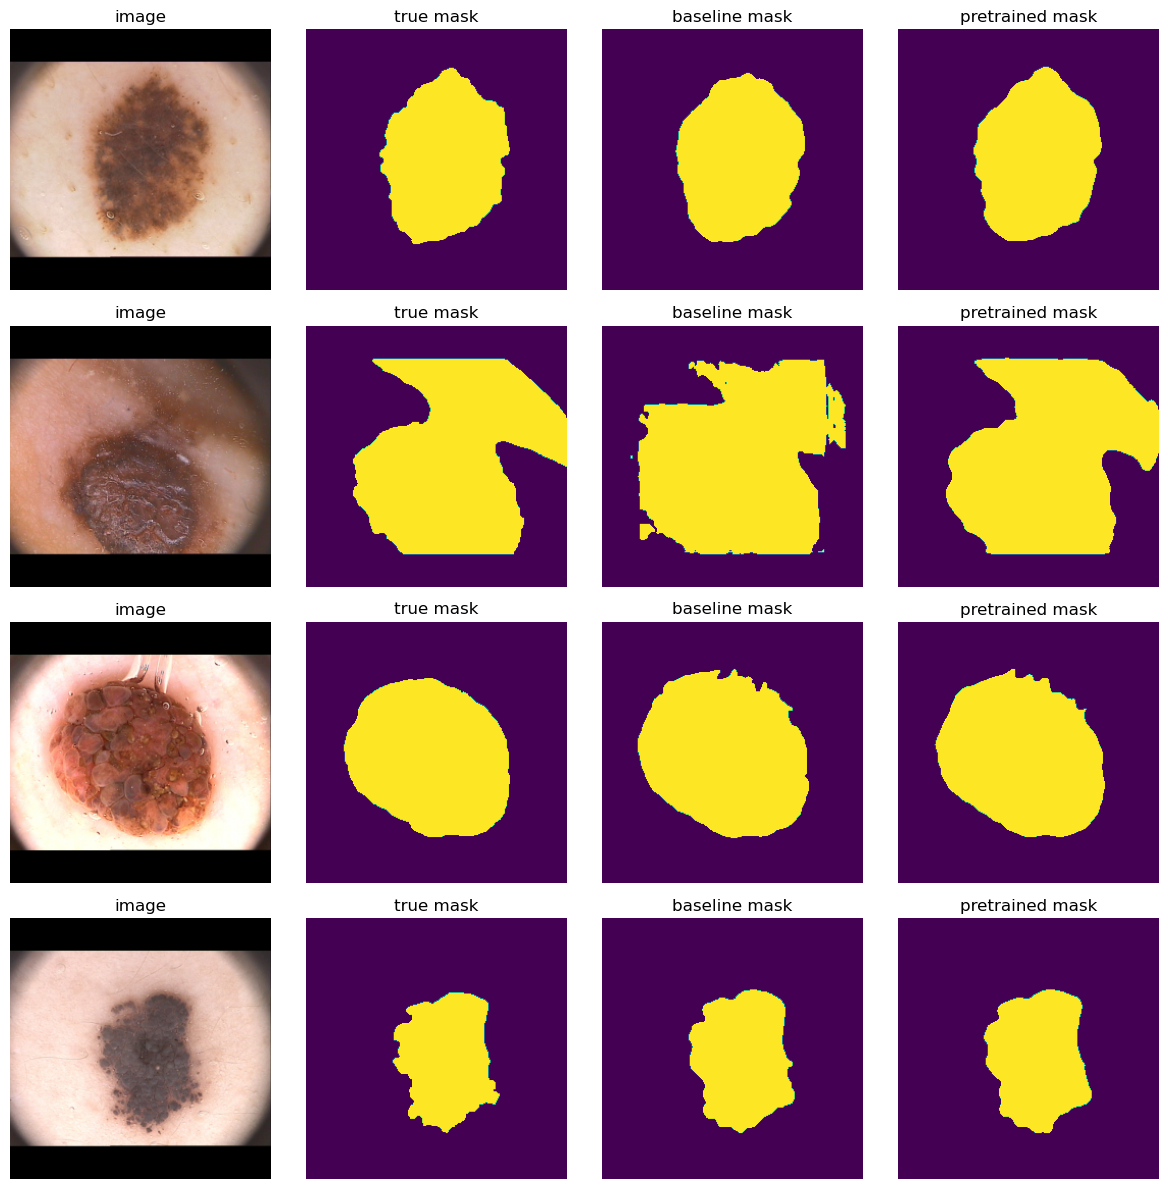

In [21]:
plt.figure(figsize=(12, 3*n))

for i in range(n):
    img = x[i].cpu().permute(1,2,0).numpy()
    true_mask = y[i,0].cpu().numpy()
    base_mask = pred_base[i,0].cpu().numpy()
    ft_mask = pred_ft[i,0].cpu().numpy()

    plt.subplot(n,4,4*i+1)
    plt.imshow(img)
    plt.title("image")
    plt.axis("off")

    plt.subplot(n,4,4*i+2)
    plt.imshow(true_mask)
    plt.title("true mask")
    plt.axis("off")

    plt.subplot(n,4,4*i+3)
    plt.imshow(base_mask)
    plt.title("baseline mask")
    plt.axis("off")

    plt.subplot(n,4,4*i+4)
    plt.imshow(ft_mask)
    plt.title("pretrained mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

baseline делает более прерывистые и резкие границы, однако, если объект имеет округлую форму, то предсказание практически ни чем не отличается от true mask

Выигрыш pretrained модели особенно заметен на сложных контурах, так его encoder даёт более качественные признаки для границы и текстуры

Посмотрим на 5 худших примеров baseline по hard dice, чтобы поняьть, где модель ошибается больше всего

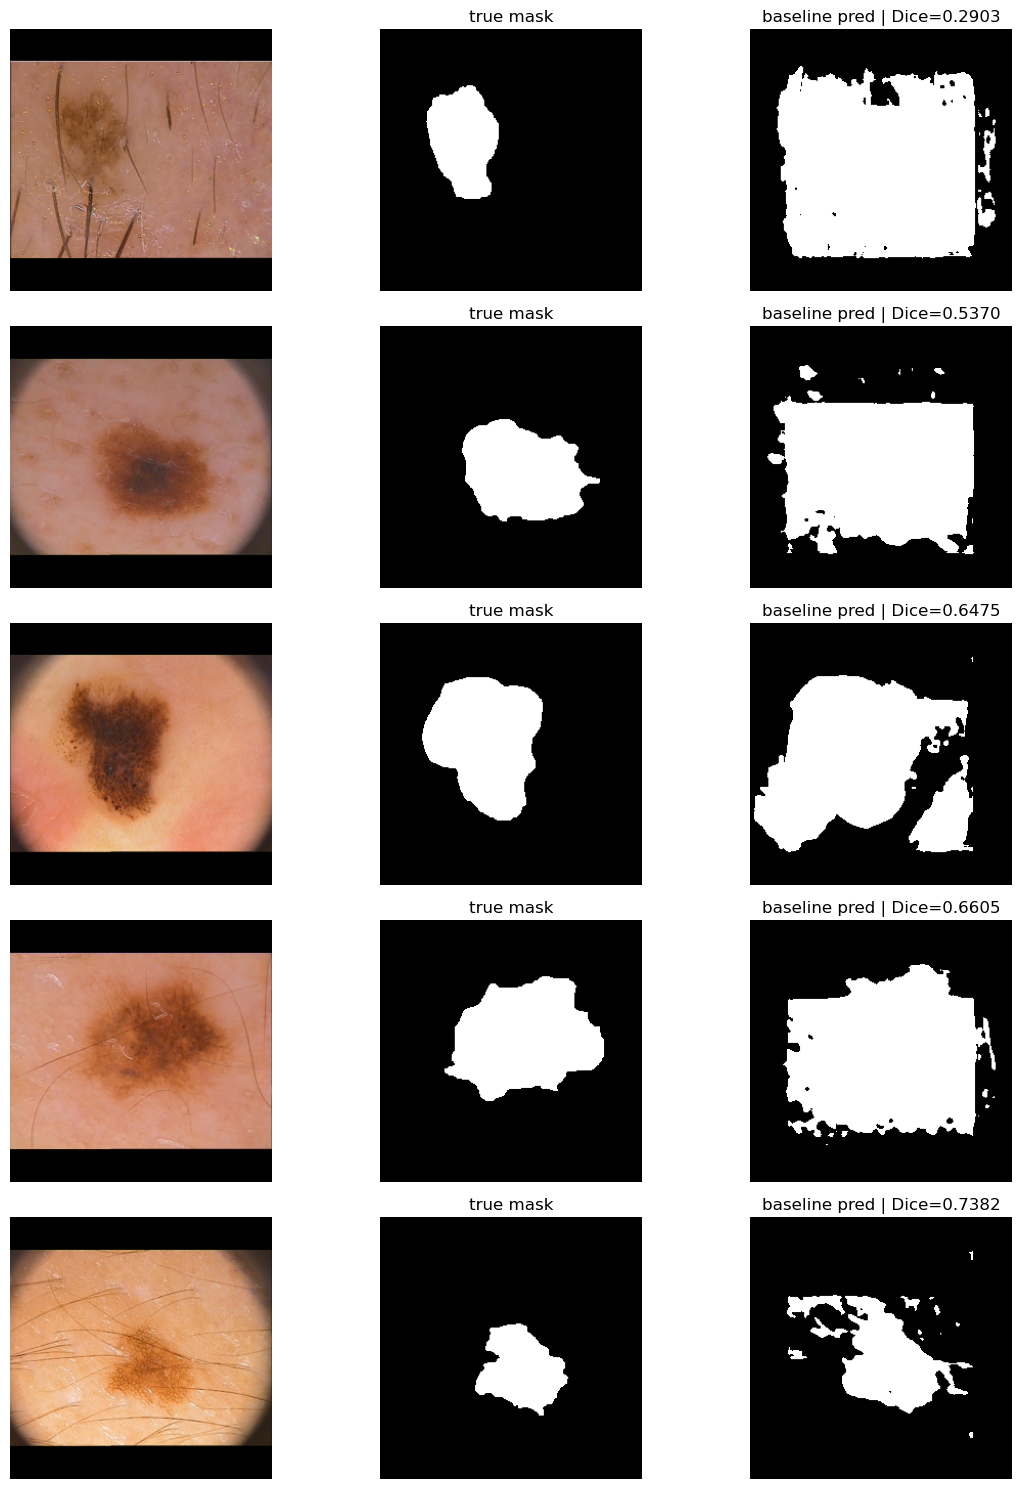

In [22]:
per_image = []

with torch.no_grad():
    for batch in val_loader:
        x = batch['image'].to(device)
        y = batch['mask'].to(device)

        logits = unet_small_model(x)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

        # считаем hard dice по каждому изображению
        for i in range(x.size(0)):
            pred_i = pred[i:i+1]
            y_i = y[i:i+1]

            inter = (pred_i * y_i).sum().item()
            sums = pred_i.sum().item() + y_i.sum().item()
            dice = (2 * inter + 1e-7) / (sums + 1e-7)

            per_image.append({
                'dice': dice,
                'image': x[i].detach().cpu(),
                'true_mask': y[i, 0].detach().cpu(),
                'pred_mask': pred[i, 0].detach().cpu(),
            })
            
per_image = sorted(per_image, key=lambda d: d['dice'])

n_show = 5
plt.figure(figsize=(12, 3*n_show))

for i in range(n_show):
    item = per_image[i]

    img = item["image"].permute(1, 2, 0).numpy()
    true_mask = item["true_mask"].numpy()
    pred_mask = item["pred_mask"].numpy()
    dice = item["dice"]

    plt.subplot(n_show, 3, 3*i + 1)
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("true mask")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title(f"baseline pred | Dice={dice:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Как оказывается, на части примеров модель плохо принимает форму объекта и цепляется за артефакты фона

Теперь найдём изображения, где разнца в dice baseline и pretrained модели максимальна, чтобы понять, где именно pretrained помогает больше всего и какие типы lesion baseline не умеет сегментировать

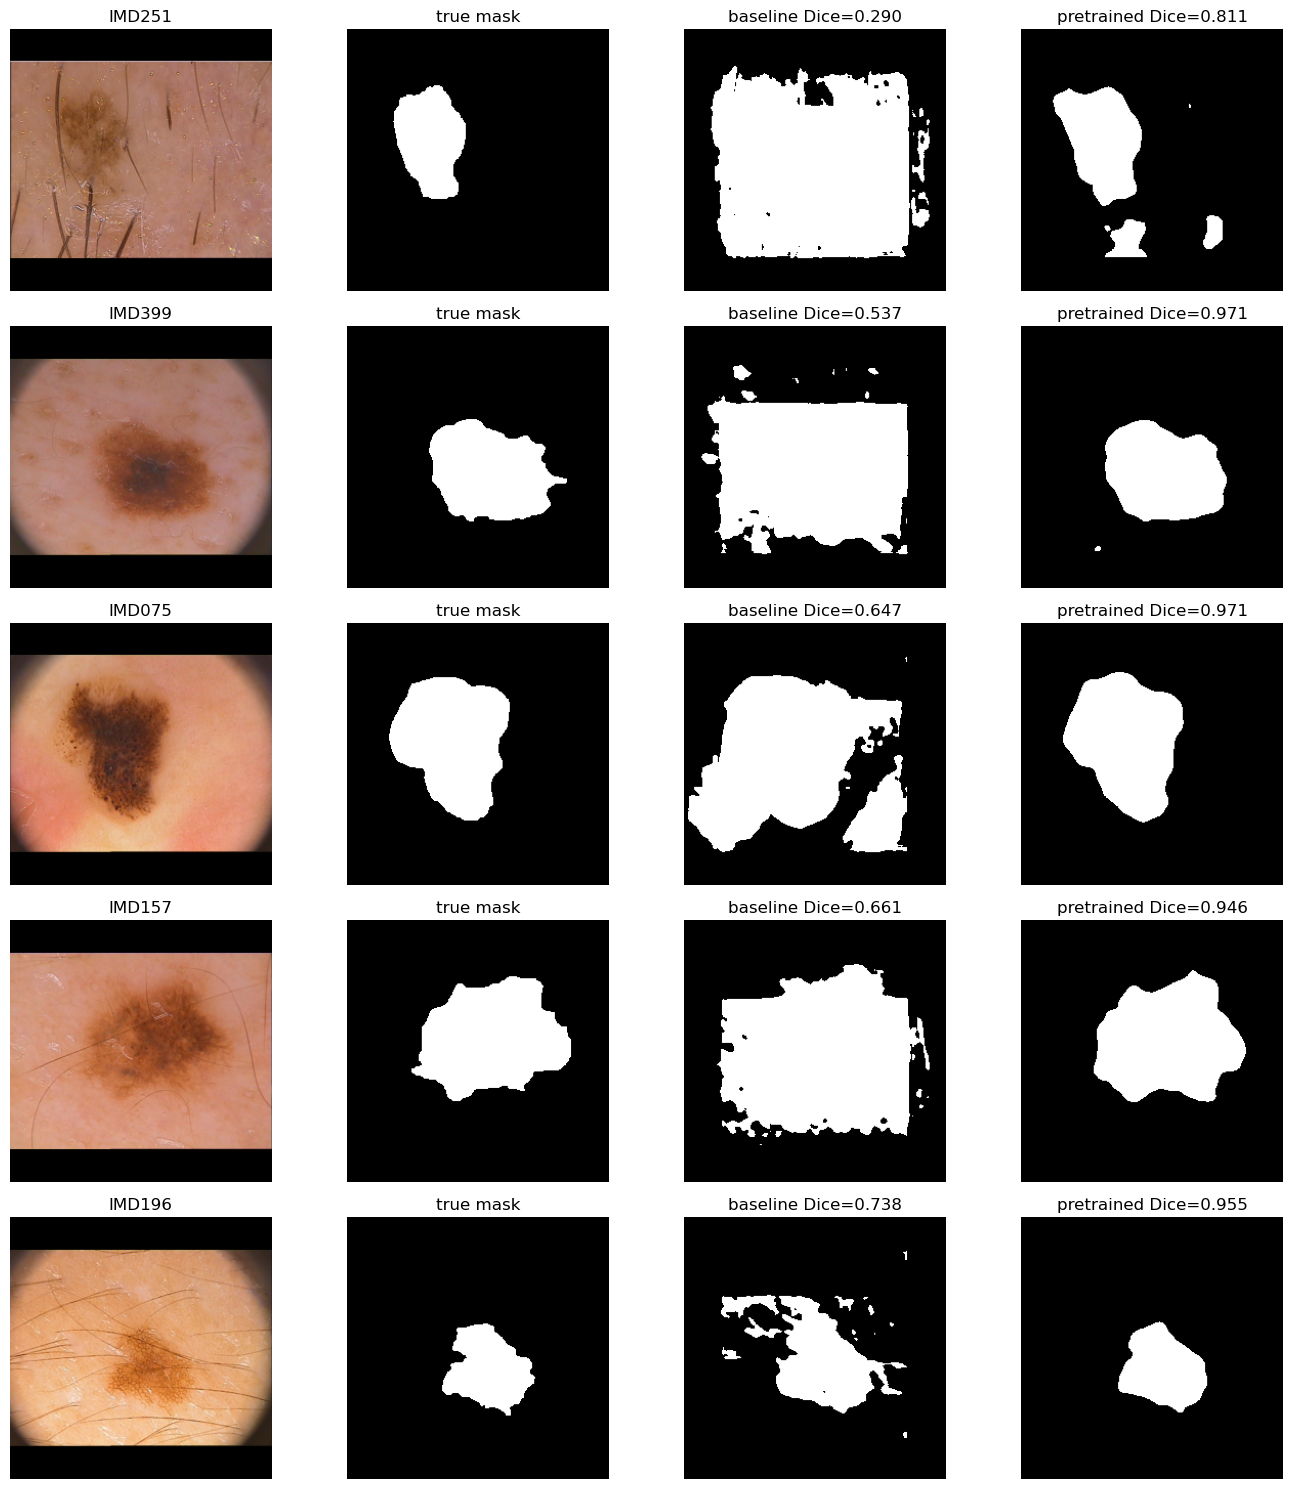

In [23]:
unet_small_model.eval()
ft_unet.eval()

cases = []

with torch.no_grad():
    for batch in val_loader:
        x = batch["image"].to(device)
        y = batch["mask"].to(device).float()
        ids = batch["id"]

        logits_base = unet_small_model(x)
        logits_ft = ft_unet(x)

        pred_base = (torch.sigmoid(logits_base) > 0.5).float()
        pred_ft = (torch.sigmoid(logits_ft) > 0.5).float()

        for i in range(x.size(0)):
            y_i = y[i:i+1]

            pb = pred_base[i:i+1]
            pf = pred_ft[i:i+1]

            inter_b = (pb * y_i).sum().item()
            dice_b = (2*inter_b + 1e-7) / (pb.sum().item() + y_i.sum().item() + 1e-7)

            inter_f = (pf * y_i).sum().item()
            dice_f = (2*inter_f + 1e-7) / (pf.sum().item() + y_i.sum().item() + 1e-7)

            gap = dice_f - dice_b

            cases.append({
                "gap": gap,
                "dice_base": dice_b,
                "dice_ft": dice_f,
                "image": x[i].cpu(),
                "true": y[i,0].cpu(),
                "base": pb[0,0].cpu(),
                "ft": pf[0,0].cpu(),
                "id": ids[i]
            })

cases = sorted(cases, key=lambda d: d["gap"], reverse=True)

n_show = 5
plt.figure(figsize=(14,3*n_show))

for i in range(n_show):
    c = cases[i]

    img = c["image"].permute(1,2,0).numpy()

    plt.subplot(n_show,4,4*i+1)
    plt.imshow(img)
    plt.title(c["id"])
    plt.axis("off")

    plt.subplot(n_show,4,4*i+2)
    plt.imshow(c["true"], cmap="gray")
    plt.title("true mask")
    plt.axis("off")

    plt.subplot(n_show,4,4*i+3)
    plt.imshow(c["base"], cmap="gray")
    plt.title(f"baseline Dice={c['dice_base']:.3f}")
    plt.axis("off")

    plt.subplot(n_show,4,4*i+4)
    plt.imshow(c["ft"], cmap="gray")
    plt.title(f"pretrained Dice={c['dice_ft']:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Проблема baseline не только в контрасте очага, а в том, что модель хуже отделяет lesion от фона и хуже восстанавливает его форму. Это может быть связано с тем, что baseline ещё не научился хорошо определять некоторые паттерны и вместо этого просто берёт большую площадь lesion, чтобы не ошибиться. То есть проблема в encoder-e.

Pretrained модель как раз имеет хорошо обученный encoder и легко определяет область очага.

## Experiments

### Thresholds

Будем менять некоторые факторы модели, обучения или метрик, чтобы лучше разобраться в архитектуре и найти более качественные настройки для модели

In [24]:
unet_small_model.eval()

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for thr in thresholds:
    hard_dice_sum = 0
    hard_iou_sum = 0
    n_bathes = 0

    with torch.no_grad():
        for batch in val_loader:
            x = batch['image'].to(device)
            y = batch['mask'].to(device)

            logits = unet_small_model(x)

            hd, hi = hard_metrics_from_logits(logits, y, thr=thr)
            hard_dice_sum += float(hd)
            hard_iou_sum += float(hi)
            n_bathes += 1

    avg_hard_dice = hard_dice_sum / n_bathes
    avg_hard_iou = hard_iou_sum / n_bathes

    print(f'thr={thr:.1f} | hard_dice={avg_hard_dice:.4f} | hard_iou={avg_hard_iou:.4f}')

thr=0.3 | hard_dice=0.8465 | hard_iou=0.7565
thr=0.4 | hard_dice=0.8555 | hard_iou=0.7678
thr=0.5 | hard_dice=0.8637 | hard_iou=0.7785
thr=0.6 | hard_dice=0.8699 | hard_iou=0.7862
thr=0.7 | hard_dice=0.8740 | hard_iou=0.7912
thr=0.8 | hard_dice=0.8738 | hard_iou=0.7900
thr=0.9 | hard_dice=0.8633 | hard_iou=0.7730


Подбор threshold до 0.7 немного улучшил итоговые hard-метрики на валидации

Теперь сравним Loss-ы

In [25]:
loss_results = {}

loss_variants = {
    "BCE": lambda logits, target: bce_logits(logits, target.float()),
    "Dice": lambda logits, target: dice_loss_fn(logits, target, eps=1e-7),
    "BCE+Dice": lambda logits, target: bce_dice_loss_fn(logits, target, alpha=1.0, beta=1.0),
}

for loss_name, loss_fn in loss_variants.items():
    print(f"\n=== Loss experiment: {loss_name} ===")

    # новая baseline-модель для честного сравнения
    exp_model = UNetSmall(in_ch=3, base_ch=32).to(device)

    optimizer = torch.optim.Adam(exp_model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        verbose=False
    )

    history_exp = fit(
        model=exp_model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fn=loss_fn,
        device=device,
        epochs=10
    )

    loss_results[loss_name] = {
        "final_val_loss": history_exp["val_loss"][-1],
        "final_soft_dice": history_exp["soft_dice"][-1],
        "final_soft_iou": history_exp["soft_iou"][-1],
        "final_hard_dice": history_exp["hard_dice"][-1],
        "final_hard_iou": history_exp["hard_iou"][-1],
        "best_hard_dice": max(history_exp["hard_dice"]),
        "best_hard_iou": max(history_exp["hard_iou"]),
    }

print("\n=== Final loss comparison summary ===")
for k, v in loss_results.items():
    print(
        f"{k:8s} | "
        f"final_hard_dice={v['final_hard_dice']:.4f} | "
        f"best_hard_dice={v['best_hard_dice']:.4f} | "
        f"final_hard_iou={v['final_hard_iou']:.4f}"
    )


=== Loss experiment: BCE ===
Epoch 01/10 | lr=1.00e-03 | train_loss=0.6406 | val_loss=0.4999 | soft_dice=0.2149 soft_iou=0.1227 | hard_dice=0.0000 hard_iou=0.0000
Epoch 02/10 | lr=1.00e-03 | train_loss=0.4523 | val_loss=0.3606 | soft_dice=0.3865 soft_iou=0.2464 | hard_dice=0.0000 hard_iou=0.0000
Epoch 03/10 | lr=1.00e-03 | train_loss=0.3569 | val_loss=0.3182 | soft_dice=0.4295 soft_iou=0.2791 | hard_dice=0.3638 hard_iou=0.2718
Epoch 04/10 | lr=1.00e-03 | train_loss=0.3567 | val_loss=0.2877 | soft_dice=0.4616 soft_iou=0.3065 | hard_dice=0.6637 hard_iou=0.5416
Epoch 05/10 | lr=1.00e-03 | train_loss=0.3414 | val_loss=0.3103 | soft_dice=0.4502 soft_iou=0.2995 | hard_dice=0.7541 hard_iou=0.6279
Epoch 06/10 | lr=1.00e-03 | train_loss=0.3341 | val_loss=0.3431 | soft_dice=0.4381 soft_iou=0.2914 | hard_dice=0.7292 hard_iou=0.6069
Epoch 07/10 | lr=5.00e-04 | train_loss=0.3729 | val_loss=0.2955 | soft_dice=0.4615 soft_iou=0.3085 | hard_dice=0.7517 hard_iou=0.6256
Epoch 08/10 | lr=5.00e-04 | trai

Для PH2 и baseline U-Net лучше всего сработал BCE+Dice

### Width

Сравним различные значения base_ch, чтобы понять, повлияет ли бОльшая ширина на качество модели

In [26]:
width_results = {}

for base_ch in [16, 32, 64]:
    print(f"\n=== Width experiment: base_ch={base_ch} ===")

    exp_model = UNetSmall(in_ch=3, base_ch=base_ch).to(device)

    optimizer = torch.optim.Adam(exp_model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        verbose=False
    )

    history_exp = fit(
        model=exp_model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fn=lambda logits, target: bce_dice_loss_fn(logits, target, alpha=1.0, beta=1.0),
        device=device,
        epochs=10
    )

    width_results[base_ch] = {
        "final_val_loss": history_exp["val_loss"][-1],
        "final_hard_dice": history_exp["hard_dice"][-1],
        "final_hard_iou": history_exp["hard_iou"][-1],
        "best_hard_dice": max(history_exp["hard_dice"]),
        "best_hard_iou": max(history_exp["hard_iou"]),
    }

print("\n=== Final width comparison summary ===")
for k, v in width_results.items():
    print(
        f"base_ch={k:2d} | "
        f"final_hard_dice={v['final_hard_dice']:.4f} | "
        f"best_hard_dice={v['best_hard_dice']:.4f} | "
        f"final_hard_iou={v['final_hard_iou']:.4f}"
    )


=== Width experiment: base_ch=16 ===
Epoch 01/10 | lr=1.00e-03 | train_loss=1.3442 | val_loss=1.2941 | soft_dice=0.2615 soft_iou=0.1550 | hard_dice=0.0000 hard_iou=0.0000
Epoch 02/10 | lr=1.00e-03 | train_loss=1.2344 | val_loss=1.0917 | soft_dice=0.3326 soft_iou=0.2050 | hard_dice=0.0000 hard_iou=0.0000
Epoch 03/10 | lr=1.00e-03 | train_loss=1.0142 | val_loss=0.9007 | soft_dice=0.4552 soft_iou=0.3059 | hard_dice=0.7197 hard_iou=0.6123
Epoch 04/10 | lr=1.00e-03 | train_loss=0.9300 | val_loss=0.9724 | soft_dice=0.4205 soft_iou=0.2782 | hard_dice=0.6473 hard_iou=0.5295
Epoch 05/10 | lr=1.00e-03 | train_loss=0.8054 | val_loss=0.5845 | soft_dice=0.7057 soft_iou=0.5780 | hard_dice=0.7541 hard_iou=0.6489
Epoch 06/10 | lr=1.00e-03 | train_loss=0.7629 | val_loss=0.6537 | soft_dice=0.6005 soft_iou=0.4511 | hard_dice=0.7442 hard_iou=0.6281
Epoch 07/10 | lr=1.00e-03 | train_loss=0.7113 | val_loss=0.5747 | soft_dice=0.6470 soft_iou=0.5002 | hard_dice=0.7614 hard_iou=0.6503
Epoch 08/10 | lr=1.00e-0

Качество предсказаний только ухудшилось, значит ширина модели почти не влияет. 
(base_ch=64 ухудшил модель, так как она просто переобучилась на маленьком датасете, имея большой capacity)

Таким образом, baseline ограничен не шириной модели, а качеством признаков encoder-a, обученного с нуля на маленьком датасете.

## Conclusion

В данной работе был реализован и исследован базовый пайплайн для задачи бинарной сегментации кожных образований на датасете PH2. Были обучены и сравнены две модели: небольшой U-Net, обученный с нуля (baseline), и U-Net с предобученным encoder-ом.

1. Baseline модель

Модель `UNetSmall`, обученная с нуля, показала удовлетворительное качество сегментации:

- **hard Dice ≈ 0.88**
- **hard IoU ≈ 0.79**

Однако анализ worst cases показал, что baseline-модель часто испытывает трудности при сегментации сложных примеров: она может предсказывать слишком большие области или неправильно восстанавливать форму lesion. Это указывает на недостаточно качественные признаки, извлекаемые encoder-ом, обученным на небольшом датасете.

---

2. Pretrained модель

Использование предобученного encoder-а (ResNet34) значительно улучшило качество сегментации:

- **hard Dice ≈ 0.95**
- **hard IoU ≈ 0.90**

Pretrained encoder обеспечивает более устойчивые визуальные признаки (контуры, текстуры и границы объектов), что позволяет модели точнее локализовать область lesion и лучше восстанавливать её форму.

---

3. Влияние функции потерь

Было проведено сравнение различных функций потерь:

| Loss | Hard Dice |
|-----|-----|
| BCE | 0.69 |
| Dice | 0.80 |
| BCE + Dice | **0.84** |

Лучшие результаты показала комбинация **BCE + Dice**, которая сочетает пиксельный сигнал BCE и глобальный сигнал перекрытия Dice.

---

4. Влияние ширины модели

Эксперимент с различной шириной baseline U-Net (`base_ch = 16, 32, 64`) показал, что увеличение количества каналов не приводит к заметному улучшению качества сегментации.

- `base_ch=16 → Dice ≈ 0.848`
- `base_ch=32 → Dice ≈ 0.847`
- `base_ch=64 → Dice ≈ 0.831`

Это указывает на то, что ограничение baseline модели связано не с недостаточной ёмкостью сети, а с качеством признаков encoder-а.

---

5. Влияние threshold

Небольшой прирост качества был получен при оптимизации порога бинаризации. Повышение threshold до **0.7** немного улучшило итоговые hard-метрики. Однако этот эффект оказался значительно менее существенным, чем влияние архитектуры модели и encoder-а.

---

Итог

Основным фактором, влияющим на качество сегментации в данной задаче, оказалось использование **предобученного encoder-а**. Даже небольшой U-Net с pretrained backbone существенно превосходит модель, обученную с нуля на ограниченном количестве данных.

Полученные результаты подтверждают, что при работе с небольшими медицинскими датасетами использование pretrained моделей является одним из наиболее эффективных способов улучшения качества сегментации.